# Polarization example (GRB) - Stokes parameters method

This notebook fits the polarization fraction and angle of a Data Challenge 3 GRB (GRB 080802386) simulated using MEGAlib and combined with albedo photon background. It's assumed that the start time, duration, localization, and spectrum of the GRB are already known. The GRB was simulated with 80% polarization at an angle of 90 degrees in the IAU convention, and was 20 degrees off-axis. A detailed description of the Stokes method, which is the approach used here to infer the polarization, is available on the [Data Challenge repository](https://github.com/cositools/cosi-data-challenges/tree/main/polarization). 

In [1]:
%%capture
from cosipy import UnBinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.polarization_fitting.polarization_stokes import (PolarizationStokes)
from cosipy.threeml.custom_functions import Band_Eflux
from cosipy.util import fetch_wasabi_file
from astropy.time import Time
import numpy as np
from astropy.coordinates import Angle, SkyCoord
from astropy import units as u
from scoords import SpacecraftFrame
from pathlib import Path

%matplotlib inline

### Download and read in data

This will download the files needed to run this notebook. If you have already downloaded these files, you can skip this.

Download the unbinned data (660.58 KB), polarization response (1.35 GB), and orientation file (1.10 GB)

In [2]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/polarization_fit/grb_background.fits.gz', checksum = '21b1d75891edc6aaf1ff3fe46e91cb49')
fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5', checksum = '46b006a6b397fd777dc561d3b028357f')
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits', checksum = 'a9163ab4852c427d09bcfe02df71173a')

Read in the data (GRB+background) and get the background by reading the files containting background before and after the GRB

In [3]:
data_path = Path("") # Update to your path

grb_plus_background = UnBinnedData(data_path/'grb.yaml')
grb_plus_background.select_data_time(unbinned_data=data_path/'grb_background.fits.gz', output_name=data_path/'grb_background_source_interval') 
grb_plus_background.select_data_energy(200., 10000., output_name=data_path/'grb_background_source_interval_energy_cut', unbinned_data=data_path/'grb_background_source_interval.fits.gz')
data = grb_plus_background.get_dict_from_fits(data_path/'grb_background_source_interval_energy_cut.fits.gz')

background_before = UnBinnedData(data_path/'background_before.yaml')
background_before.select_data_time(unbinned_data=data_path/'grb_background.fits.gz', output_name=data_path/'background_before')
background_before.select_data_energy(200., 10000., output_name=data_path/'background_before_energy_cut', unbinned_data=data_path/'background_before.fits.gz')
background_1 = background_before.get_dict_from_fits(data_path/'background_before_energy_cut.fits.gz')

background_after = UnBinnedData(data_path/'background_after.yaml') # e.g. background_after.yaml
background_after.select_data_time(unbinned_data=data_path/'grb_background.fits.gz', output_name=data_path/'background_after')
background_after.select_data_energy(200., 10000., output_name=data_path/'background_after_energy_cut', unbinned_data=data_path/'background_after.fits.gz')
background_2 = background_after.get_dict_from_fits(data_path/'background_after_energy_cut.fits.gz')

background = [background_1, background_2]
# Save background_1 dictionary to a file npz
np.savez(data_path/'background_1.npz', **background_1)

Read in the response files and the orientation file. Here, the spacecraft is stationary, so we are only using the first attitude bin ( The orientation is cut down to the time interval of the source.)

In [4]:
response_file = data_path/'ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5'

sc_orientation = SpacecraftHistory.open(data_path/'DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits',
                                        tstart = Time(1835493492.2, format = 'unix'), tstop = Time(1835493492.8, format = 'unix')) # e.g. DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits

Define the GRB spectrum. This is convolved with the response to calculate the ASADs of an unpolarized and 100% polarized source

In [5]:
source_direction = SkyCoord(l=23.53, b=-53.44, frame='galactic', unit=u.deg)

a = 100. * u.keV
b = 10000. * u.keV
alpha = -0.7368949
beta = -2.095031
ebreak = 622.389 * u.keV
K = 300. / u.cm / u.cm / u.s

spectrum = Band_Eflux(a = a.value,
                      b = b.value,
                      alpha = alpha,
                      beta = beta,
                      E0 = ebreak.value,
                      K = K.value)

spectrum.a.unit = a.unit
spectrum.b.unit = b.unit
spectrum.E0.unit = ebreak.unit
spectrum.K.unit = K.unit

Define the source position and polarization object

In [6]:
source_photons = PolarizationStokes(source_direction, spectrum, data, response_file, sc_orientation, 
                                    background=background, response_convention='RelativeX', show_plots=False)

This class loading takes around 30 seconds... 

Number of azimuthal angle bins used: 12
>>> Convolving spectrum in ICRS frame...
Energy range considered (by responses design): 200.0 - 10000.0 keV
Background provided. Make sure there is enough statistics.
Creating the 100% polarized ASADs (this may take a minute...)
Creating the unpolarized ASAD...
A = 0.72, B = 0.57, C = 1.53
Rmax, Rmin: 1.2827367006245693 0.7181276431368199
Modulation mu =  0.28218257736871405
A = 0.71, B = 0.58, C = 1.24
Rmax, Rmin: 1.284622321399381 0.7145058020894187
Modulation mu =  0.2851825816521541
A = 0.71, B = 0.58, C = 0.99
Rmax, Rmin: 1.2794216149597286 0.7123734684134967
Modulation mu =  0.2846920103778455
A = 0.71, B = 0.58, C = 0.73
Rmax, Rmin: 1.2823360713534138 0.7078568845720508
Modulation mu =  0.28865501964065743
A = 0.71, B = 0.59, C = 0.48
Rmax, Rmin: 1.2856339600280398 0.7071225736365377
Modulation mu =  0.2903071080778991
A = 0.71, B = 0.58, C = 0.21
Rmax, Rmin: 1.2853837198507168 0.707852533305

Let's check some numbers:

In [7]:
data_duration = source_photons.get_data_duration()
data_count = source_photons.get_data_counts()
print('\nData duration:', str(round(data_duration, 3)), 's')
print('Data counts:', str(data_count))
print('Count rate:', str(round(data_count / data_duration, 3)), 'counts/s')

background_duration = source_photons.get_background_duration()
print('\nBackground duration:', str(round(background_duration, 3)), 's')

MDP99 = source_photons._mdp99 * 100
print('\nMDP_99:', str(round(MDP99, 3)), '%')


Data duration: 0.541 s
Data counts: 8114
Count rate: 15006.507 counts/s

Background duration: 378.9 s

MDP_99: 16.646 %


Derive the modulation factor. This depends on the source spectrum and the instrument polarization response averaged over polarization angles. This steo needs to be re-computed for every source.

In [8]:
average_mu = source_photons._mu100
mu = average_mu['mu']
mu_err = average_mu['uncertainty']

print('modulation factor: %.3f +/- %.3f'%(mu, mu_err))

modulation factor: 0.286 +/- 0.000


Get the azimuthal angles for each photons and calculate the Pseudo Stokes parameters from the scattering angle for each photon in the data and background simulation

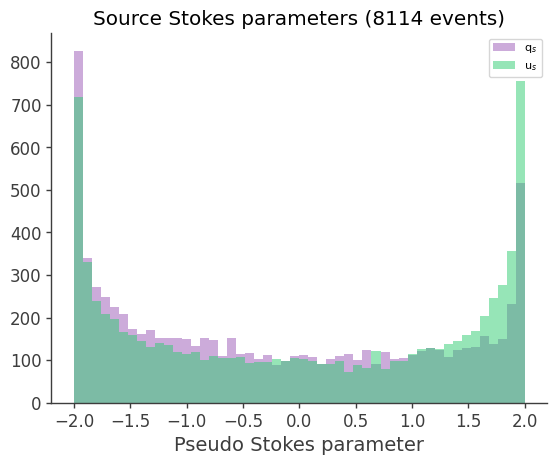

In [9]:
qs, us = source_photons.compute_data_pseudo_stokes(show_plots=True)

Now get the stokes parameters for the background observations

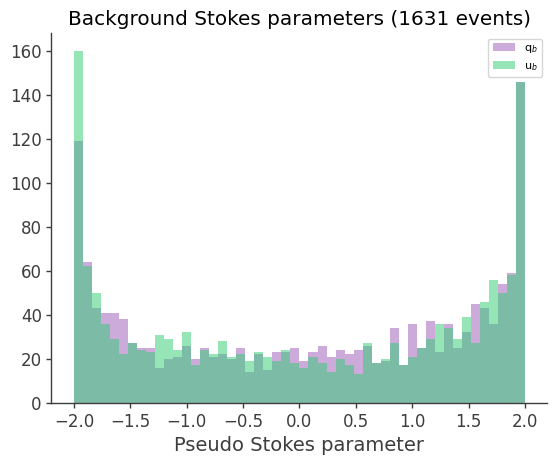

In [10]:
bkg_qs, bkg_us = source_photons.compute_background_pseudo_stokes(show_plots=True)

The background is rate is estimated over a longer time period and therefore its flux needs to be rescaled to the expected flux during the GRB.

This factor is simply computed as the ration of GRB duration / background duration.

In [11]:
backscal = source_photons.get_backscal()

print('Background scale factor:', backscal)
print('Consistency check :', data_duration/background_duration == backscal)

Background scale factor: 0.0014270214696478288
Consistency check : True


Compute the expected MDP assuming 

I, Q, U, mu 8114 -6748.662921595113 679.1013368480847 0.286103474003816
Q, U (unsubtracted:) -0.831730702686112 0.08369501316836143
Unpolarized bkg (or simulation) provided, subtracting its contribution.
check I(src+bkg) vs I(src): 8114 8111.672527983004
Q, U unpolarized: 0.30927296257871145 0.1280049674500421
Q, U unpolarized uncertainty: 323.2597643589276 %
Q, U, subtracted: -0.8312893635285307 0.08387767900513422
Q/I, U/I, uncertainty: 0.044400158330688354 0.05478623413101503 0.2107134507588169

 ############################## 

     PD: 83.55 +/- 5.41 %
     PA: 87.12 +/- 1.88 deg

 ############################## 



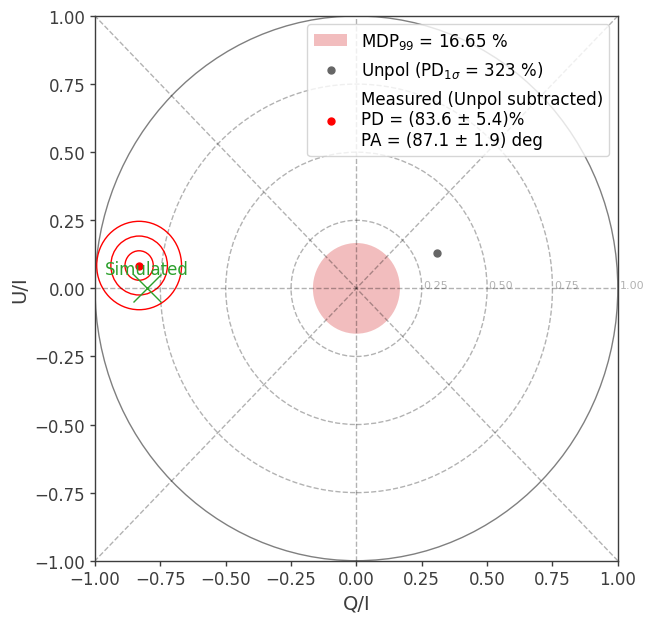

In [12]:
polarization = source_photons.calculate_polarization(qs, us, mu, bkg_qs=bkg_qs, bkg_us=bkg_us, show_plots=True, ref_pdpa=(0.8, 90), ref_label='Simulated', mdp=MDP99/100)

Extracting the informations from the polarization dictionary:

In [13]:
Pol_frac = polarization['fraction'] * 100
Pol_frac_err = polarization['fraction_uncertainty'] * 100
print('Polarization degree: (%.2f +/- %.2f) %%'%(Pol_frac, Pol_frac_err))

Pol_angle = polarization['angle'].angle.degree
Pol_angle_err = polarization['angle_uncertainty'].degree
print('Polarization angle: (%.2f +/- %.2f) deg'%(Pol_angle, Pol_angle_err))

Normalized_Q = polarization['QN']
Normalized_U = polarization['UN']
QN_ERR = polarization['QN_ERR']
UN_ERR = polarization['UN_ERR']
print('Normalized Q: %.3f +/- %.3f'%(Normalized_Q, QN_ERR))
print('Normalized U: %.3f +/- %.3f'%(Normalized_U, UN_ERR))



Polarization degree: (83.55 +/- 5.41) %
Polarization angle: (87.12 +/- 1.88) deg
Normalized Q: -0.831 +/- 0.044
Normalized U: 0.084 +/- 0.055
